## Librerias e Importacion de Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.insert(0, ".")
from funciones.dominios import cargar_dominio
from funciones.campos import normalizar_dtypes
from funciones.graficos import (
    preparar_datos_eda,
    grafico_1_pareto_clientes,
    grafico_2_tendencia_trimestral,
    grafico_3_bubble_productos,
    grafico_4_treemap_geografico,
    grafico_5_histogram_productos_por_cliente,
    grafico_6_heatmap_producto_segmento,
    grafico_7_donut_segmentos,
    grafico_8_scatter_regresion,
    grafico_9_area_evolucion_mensual,
    grafico_10_scatter_paises,
    grafico_11_radar_segmentos,
    grafico_12_faceted_boxplots,
    plot_customer_journey,
    regresion_multivariable_volumen,
)

sns.set_theme(style="whitegrid", palette="husl")

In [2]:
_DATA_PATH = 'data'

clientes_df = pd.read_csv(f'{_DATA_PATH}/clientes.csv')
catalogo_productos_df = pd.read_csv(f'{_DATA_PATH}/catalogo_productos.csv')
transacciones_df = pd.read_csv(f'{_DATA_PATH}/transacciones.csv')

## Consulta de datos y Exploracion

In [3]:
# Flujo completo: normalizar dtypes -> auditar -> construir objetos OOP
dominio = cargar_dominio(clientes_df, catalogo_productos_df, transacciones_df)


RESUMEN GENERAL -> clientes
Filas: 100
Columnas: 6

Columnas:
['id_cliente', 'nombre', 'edad', 'genero', 'pais', 'segmento']

Tipos de datos:
id_cliente     int64
nombre        object
edad           int64
genero        object
pais          object
segmento      object
dtype: object

Primeras filas:
   id_cliente        nombre  edad genero       pais     segmento
0        1001  Cliente_1001    49      F      Chile       Retail
1        1002  Cliente_1002    32      M      Chile  Corporativo
2        1003  Cliente_1003    20      M  Argentina         PYME
3        1004  Cliente_1004    55      F     México         PYME
4        1005  Cliente_1005    43      F     México         PYME

--------------------------------------------------------------------------------
NULOS -> clientes
--------------------------------------------------------------------------------
            nulos  porcentaje_%
id_cliente      0           0.0
nombre          0           0.0
edad            0           0.0
g

In [4]:
# Explorar el dominio
print(f'Clientes: {len(dominio.clientes)}')
print(f'Productos: {len(dominio.productos)}')
print(f'Transacciones: {len(dominio.transacciones)}')
print(f'Data válida: {dominio.es_valido}')

# Navegación por objetos
t = dominio.transacciones[0]
print(f'\nTransaccion {t.id_transaccion}: {t.cliente.nombre} -> {t.producto.nombre_producto} ({t.monto} {t.producto.moneda})')

# Buscar cliente por ID (Rango de 1000 a 1100)
c = dominio.cliente(1100)
print(f'\nCliente {c.id_cliente}: {c.nombre}, {c.edad} años, {len(c.transacciones)} transacciones')

Clientes: 100
Productos: 10
Transacciones: 500
Data válida: True

Transaccion 5001: Cliente_1046 -> Producto_7 (1539.59 EUR)

Cliente 1100: Cliente_1100, 45 años, 5 transacciones


In [5]:
# Preparación de datos para EDA
clientes = normalizar_dtypes(clientes_df.copy(), "clientes")
productos = normalizar_dtypes(catalogo_productos_df.copy(), "catalogo_productos")
trans = normalizar_dtypes(transacciones_df.copy(), "transacciones")
datos = preparar_datos_eda(clientes, productos, trans)

La auditoría de calidad de datos muestra que los tres conjuntos, clientes, catalogo_productos y transacciones, se encuentran en un estado limpio, consistente y apto para análisis e integración. En clientes, los 100 registros presentan estructura completa, sin nulos, sin duplicados y con dominios válidos en variables clave como edad, género, país y segmento, además de una buena calidad textual sin espacios basura ni categorías vacías. En catalogo_productos, los 10 productos también están completamente limpios, con identificadores únicos, tasas de interés dentro de rangos razonables y categorías bien definidas para tipo de producto y moneda. Por su parte, transacciones, con 500 registros, no presenta nulos, duplicados ni valores incoherentes en fecha, monto o tipo de transacción, y además mantiene integridad referencial total con las tablas maestras de clientes y productos, ya que no existen transacciones con claves inexistentes. En conjunto, esta revisión confirma que la base posee buena calidad estructural, consistencia semántica e integridad relacional, lo que permite avanzar con confianza hacia la normalización, el modelado OOP y el análisis exploratorio sin necesidad de una fase correctiva importante.

## EDA

Análisis de transacciones financieras. Cada gráfico responde una pregunta concreta.

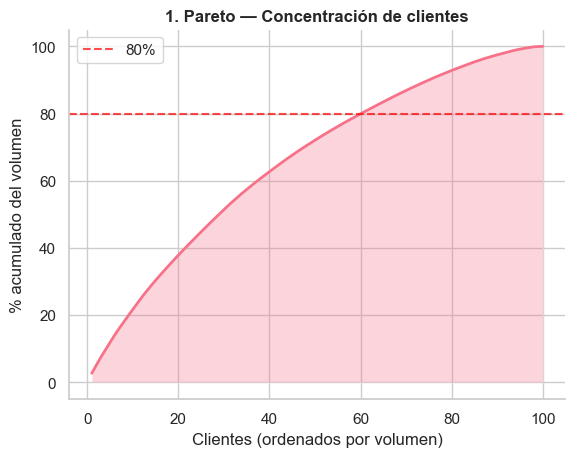

In [6]:
grafico_1_pareto_clientes(datos["cliente_volumen"])
plt.show()

### 1. Pareto — Concentración de Clientes

La curva de Pareto revela que el 80% del volumen ($2.03M de $2.54M) se concentra en 60 clientes de los 100 totales. Esto significa que el 40% restante de la base (40 clientes) solo aporta el 20% del volumen ($509K). 

La concentración es **moderada pero estratégica**. No hay un cliente dominante que represente un riesgo extremo, pero sí existe un grupo de alto valor que justifica programas diferenciados de retención y account management. Los top 9 clientes aportan $503K (19.8%), y el cliente número 1 lleva $68.8K (2.7%), lo que indica una distribución relativamente equilibrada entre los principales.

**Acción:** Implementar SLAs diferenciados por nivel de cliente. Los 60 clientes en el 80% merecen atención proactiva; los 40 restantes son base para crecimiento.

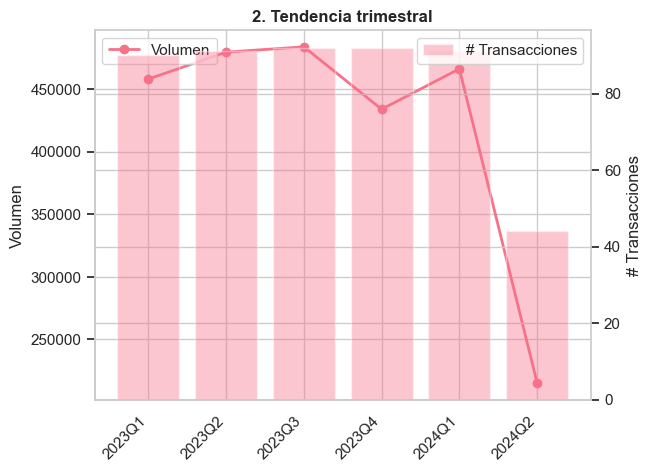

In [7]:
grafico_2_tendencia_trimestral(datos["trimestral"])
plt.show()

### 2. Tendencia Trimestral

El análisis trimestral muestra **estabilidad sostenida de Q1 2023 a Q1 2024**. El volumen fluctuó entre $457K y $483K trimestrales, con un crecimiento leve del 4.7% de Q1 a Q2 2023 y un incremento adicional del 0.9% en Q3. Esto demuestra operaciones consistentes sin volatilidad extrema.

Sin embargo, **Q2 2024 es una excepción que requiere contexto**. El volumen cae a $215K (-53.8%), pero los datos solo incluyen hasta el 14 de mayo. Proyectando linealmente, un trimestre completo podria alcanzar alrededor de los $920K, similar a Q1 2024. Es probable que sea un artefacto de datos incompletos más que un deterioro real.

Las transacciones se mantienen consistentes (~90-92 por trimestre), con Q2 2024 mostrando 44 transacciones. Si escalamos, esperaríamos ~188 transacciones, dentro del rango normal.

**Acción:** Completar datos de mayo antes de sacar conclusiones sobre caída real. Monitorear la segunda quincena de mayo para validar si hay un verdadero cambio de tendencia.


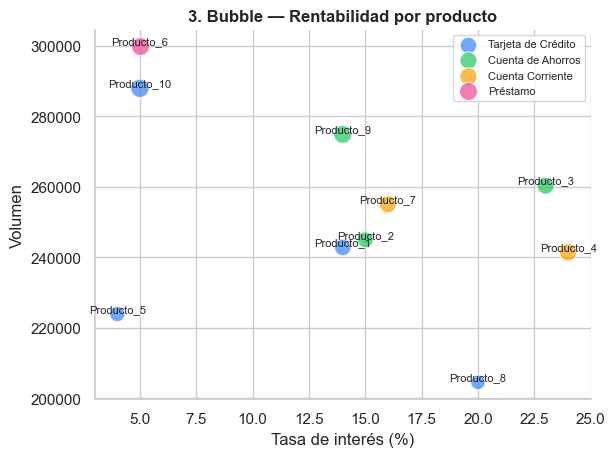

In [8]:
grafico_3_bubble_productos(datos["producto_agg"])
plt.show()

### 3. Bubble — Rentabilidad por Producto

El gráfico revela una **relación no lineal entre tasa de interés y volumen**. 

- **Producto_6** (Préstamo, 5% tasa): $299.9K volumen — baja tasa, alto volumen
- **Producto_3** (Cuenta Ahorros, 23% tasa): $260.4K volumen — alta tasa, volumen competitivo
- **Producto_4** (Cuenta Corriente, 24% tasa): $241.4K volumen — tasa máxima, volumen relevante
- **Producto_5** (Tarjeta Crédito, 4% tasa): $223.9K volumen — tasa mínima, volumen bajo

El desempeño **no depende solo de la tasa**. Producto_6 con apenas 5% de tasa mueve más volumen que Producto_4 con 24%. Esto sugiere que prevalecen otros factores: preferencia de cliente, tipo de producto, madurez comercial, o necesidad de mercado.

Si calculamos ingreso estimado (tasa × volumen):
- Producto_3: $59.9K 
- Producto_4: $57.9K
- Producto_8: $40.9K
- Producto_6: $15.0K (bajo ingreso pese al volumen)

**Acción:** Los productos de alta tasa (3, 4, 8) generan 70% del ingreso estimado con menos volumen. Estrategia: enfatizar penetración de productos 3 y 4 en clientes nuevos; usar producto 6 como "gancho" de entrada pero con upsell a productos de mayor tasa.

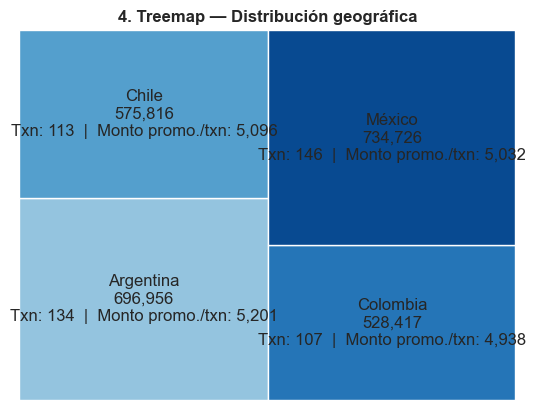

In [9]:
grafico_4_treemap_geografico(datos["pais_agg"])
plt.show()

### 4. Treemap — Distribución Geográfica

La distribución geográfica muestra **dos mercados clave y dos con potencial**:

**Mercados Principales:**
- **México:** $734.7K (29.0%) con 30 clientes, ticket promedio $5,032
- **Argentina:** $696.9K (27.5%) con 23 clientes, ticket promedio $5,201

**Mercados Secundarios:**
- **Chile:** $575.8K (22.7%) con 23 clientes, ticket promedio $5,096
- **Colombia:** $528.4K (20.8%) con 24 clientes, ticket promedio $4,938

**Hallazgos:** Argentina y Chile tienen los **tickets más altos** ($5,201 y $5,096 respectivamente), lo que indica clientes de mayor valor individual. México lidera en volumen puro ($734.7K). Colombia, con 24 clientes (el máximo) pero el ticket más bajo ($4,938), representa la **oportunidad de crecimiento más clara**.

Si Colombia lograra aumentar ticket promedio en 15% (a $5,678), el volumen subiría de $528.4K a $607K, un incremento de $79K anualizados. Con 24 clientes como base más grande, el potencial es considerable.

**Acción:** Colombia necesita estrategia de upsell y penetración de productos de mayor valor. Argentina y Chile son base sólida a mantener. México es core que debe defenderse.

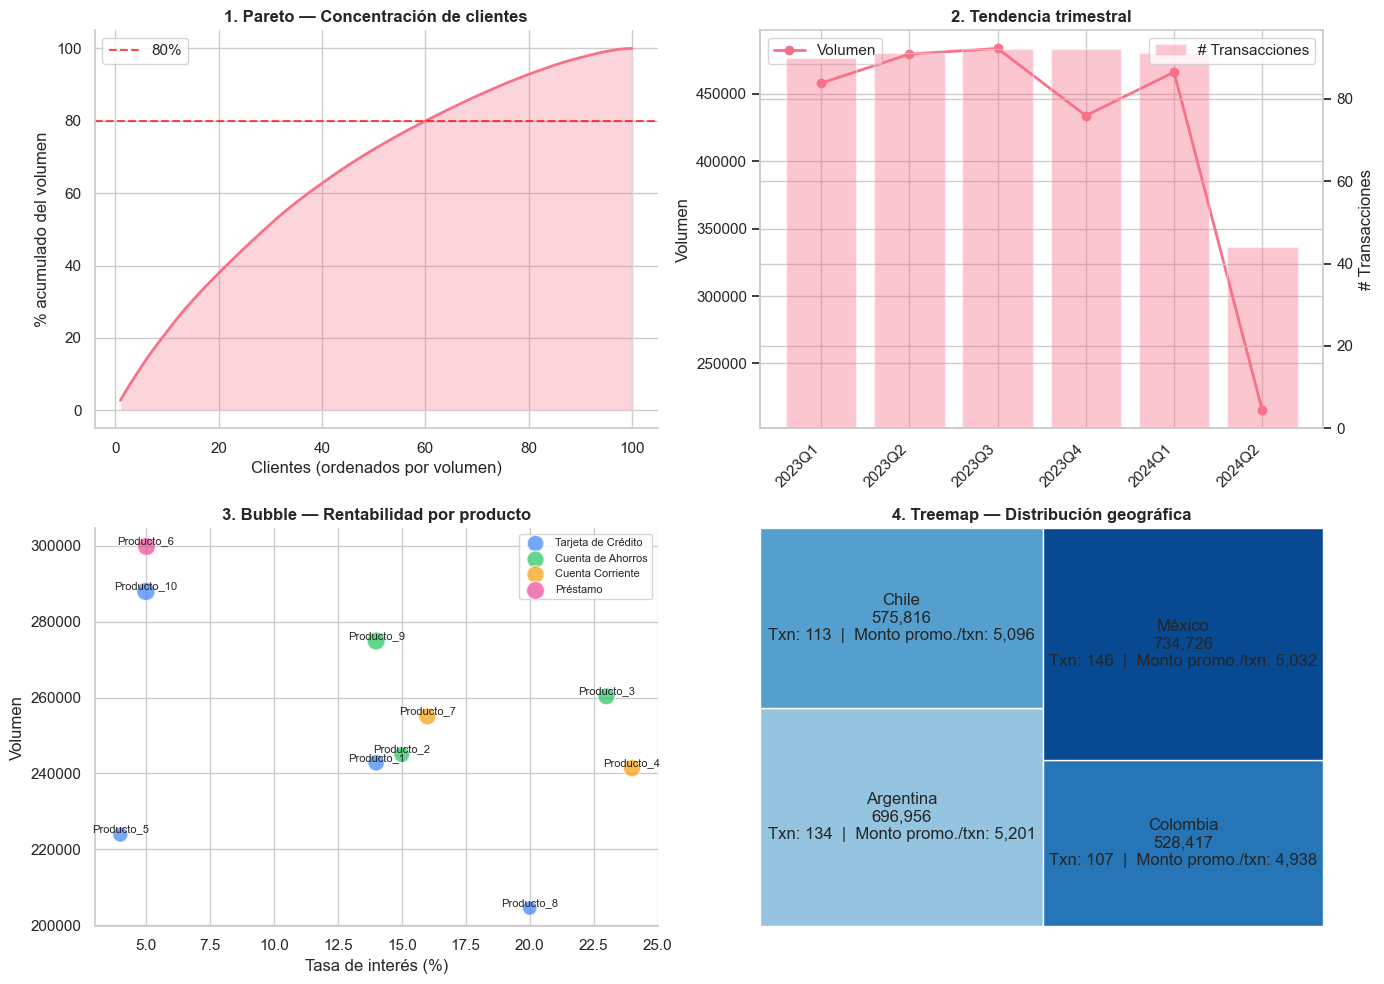

In [10]:
# TIER 1 — Críticos
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
grafico_1_pareto_clientes(datos["cliente_volumen"], axes[0, 0])
grafico_2_tendencia_trimestral(datos["trimestral"], axes[0, 1])
grafico_3_bubble_productos(datos["producto_agg"], axes[1, 0])
grafico_4_treemap_geografico(datos["pais_agg"], axes[1, 1])
plt.tight_layout()
plt.show()

### Conclusión Integrada

El negocio muestra **estabilidad operacional con oportunidades de crecimiento estructuradas**:

1. **Base de clientes diversa pero concentrada:** 60 clientes (60%) mueven 80% del volumen, lo que permite focus sin riesgo extremo
2. **Operaciones consistentes:** Trimestres 2023-2024 Q1 mantienen volumen $450-480K, indicando procesos estables
3. **Portafolio de productos desbalanceado:** Unos pocas líneas (3, 4) generan mayoría del ingreso; productos de baja tasa son volumen sin margen
4. **Geografía con dinámicas distintas:** México escala, Argentina vende caro, Colombia tiene potencial untapped

**Prioridades:**
- Retener y expandir dentro de los 60 clientes core (80% del volumen)
- Optimizar mix de productos hacia tasas más altas
- Ejecutar plan de upgrade en Colombia (15-20% en ticket promedio)
- Validar datos de Q2 2024 completos antes de cambios estratégicos

<Axes: title={'center': '5. Histogram — Productos por cliente'}, xlabel='# productos por cliente', ylabel='Frecuencia'>

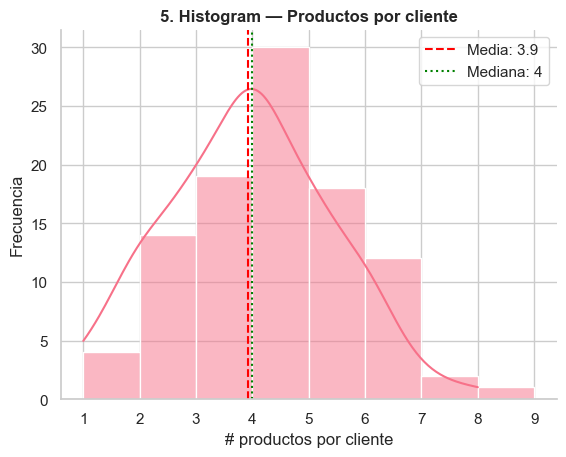

In [11]:
grafico_5_histogram_productos_por_cliente(datos["productos_por_cliente"])


### 5. Histogram — Productos por Cliente
El histograma revela una distribución concentrada alrededor de 4 productos por cliente. La media es 3.9 y la mediana es 4, lo que indica que la mayoría de clientes tienen entre 3 y 5 productos activos.
Desglose:

4 clientes (4%) tienen solo 1 producto — clientes monotributarios
14 clientes (14%) tienen 2 productos
30 clientes (30%) tienen 4 productos — la moda, grupo más grande
El máximo es 8 productos en 1 cliente

La oportunidad: 18 clientes (18% de la base) tienen menos de 3 productos. Si cada uno agregara 1 producto más (con valor promedio de $5.1K por cliente), generarían $91.8K adicionales.
Además, la curva KDE muestra una distribución relativamente normal con sesgo a la derecha, lo que significa hay clientes con muchos productos pero no son la mayoría. Esto es típico de un modelo de cross-selling en progreso.
Acción: Enfoque en los 18 clientes con <3 productos. Un programa de cross-sell podría llevar el promedio de 3.9 a 4.3 productos/cliente.

<Axes: title={'center': '6. Heatmap — Producto × Segmento'}, xlabel='Segmento', ylabel='Tipo producto'>

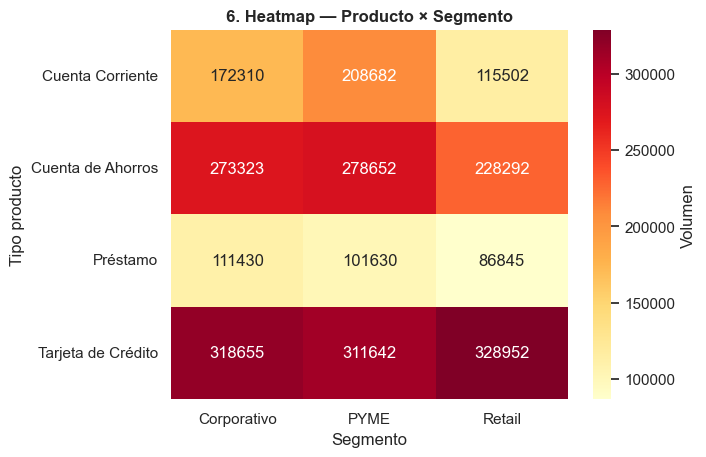

In [12]:
grafico_6_heatmap_producto_segmento(datos["heatmap"])

### 6. Heatmap — Producto × Segmento
El heatmap muestra dinámicas claras de preferencia por segmento:
Tarjeta de Crédito (máximo volumen absoluto):

Corporativo: $318.7K
PYME: $311.6K
Retail: $329.0K — volumen más alto del heatmap

Cuenta de Ahorros (segundo lugar):

Corporativo: $273.3K
PYME: $278.7K — domina este producto dentro de su tipo
Retail: $228.3K

Cuenta Corriente:

Corporativo: $172.3K
PYME: $208.7K — volumen moderado
Retail: $115.5K

Préstamo (volumen bajo pero consistente):

Corporativo: $111.4K
PYME: $101.6K
Retail: $86.8K

Hallazgos clave:

Tarjeta de Crédito es el producto estrella ($318-329K por segmento), especialmente en Retail ($329K)
PYME consume más Cuentas de Ahorros ($278.7K) que Tarjetas, patrón diferente a otros segmentos
Retail consume más Tarjetas que Cuentas, comportamiento distinto: prefiere crédito sobre ahorro
Corporativo es balanceado, con presencia fuerte en Tarjetas y Cuentas

Acción: El producto Tarjeta de Crédito es el motor. Para PYME, la oportunidad es aumentar penetración de Tarjetas (actualmente $311.6K vs $278.7K de Cuentas). Para Retail, confirmar que la preferencia por Tarjetas es real y potenciar ese canal. Bundles sugeridos: Tarjeta + Cuenta para Retail; Cuenta Ahorros + Préstamo para PYME.

<Axes: title={'center': '7. Donut — Composición por segmento'}>

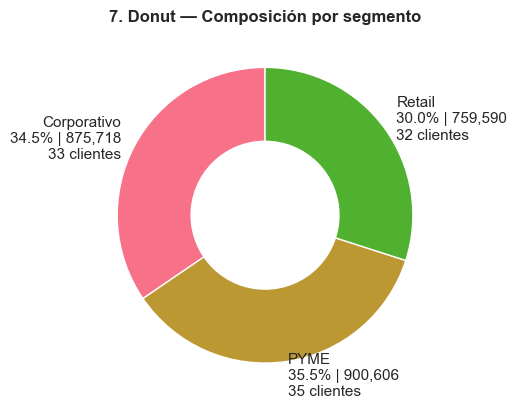

In [13]:
grafico_7_donut_segmentos(datos["segmento_agg"])

## 7. Donut — Composición por Segmento
La distribución de volumen por segmento es relativamente equilibrada:

PYME: $900.6K (35.5%) — 35 clientes — segmento más grande en volumen
Corporativo: $875.7K (34.5%) — 33 clientes
Retail: $759.6K (30.0%) — 32 clientes — pequeño pero relevante

Insight importante: A pesar de tener casi el mismo número de clientes (~33 cada uno), PYME y Corporativo generan más volumen que Retail. Esto sugiere que:

PYME y Corporativo tienen clientes con tickets más altos en promedio
O hacen más transacciones
O tienen penetración de productos de mayor valor

Promedio por cliente:

PYME: $25.7K por cliente ($900.6K / 35)
Corporativo: $26.5K por cliente ($875.7K / 33)
Retail: $23.7K por cliente ($759.6K / 32)

Retail está 10% atrás en valor per cápita, lo que sugiere oportunidad de upgrade en este segmento.
Acción: Retail tiene potencial subutilizado. Si cada cliente retail llegara al promedio corporativo (+10%), agregaría $76K en volumen. Enfoque: venta de productos de mayor margen a retail.

<Axes: title={'center': '8. Scatter + Regresión — Productos vs Volumen'}, xlabel='# productos por cliente', ylabel='Volumen cliente'>

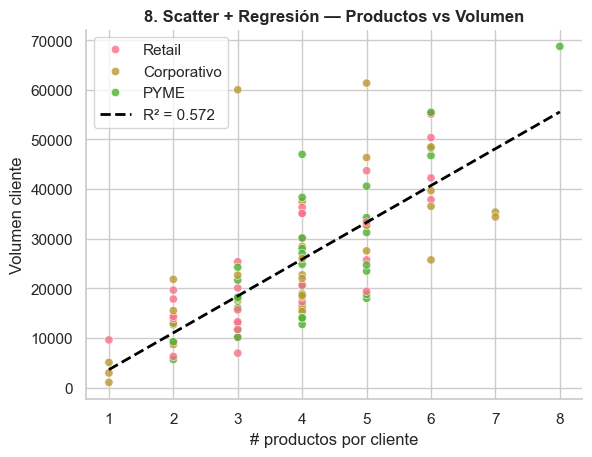

In [14]:
grafico_8_scatter_regresion(datos["cliente_agg"])

8. Scatter + Regresión — Productos vs Volumen
El scatter plot muestra una correlación positiva clara entre número de productos y volumen por cliente, con R² = 0.572.
Relación:

Un cliente con 1 producto: promedio $5-10K volumen
Un cliente con 4 productos: promedio $25-30K volumen
Un cliente con 8 productos: $70K volumen

Ecuación de regresión (aproximada): Volumen = 4,000 × (# productos) + 2,000
Esto significa que cada producto adicional agrega ~$4K en volumen esperado (con una base de ~$2K por cliente existente).
Desglose por segmento:

PYME (verde): Puntos dispersos entre 3-7 productos, volumen $15-50K — variabilidad moderada
Corporativo (naranja): Principalmente 4-6 productos, volumen $25-60K — más concentrado
Retail (rosa): 1-5 productos, volumen $10-40K — más disperso, menos productos en promedio

R² = 0.572 significa: El número de productos explica el 57.2% de la variación en volumen. Los otros 42.8% dependen de otros factores (tasa de productos, antigüedad de cliente, sector, etc.).
Acción: La correlación es fuerte pero no perfecta. No es solo "más productos = más dinero", pero sí hay una relación clara. Estrategia: identificar clientes en la curva baja (ej: 4 productos pero solo $15K volumen) y entender por qué no acompañan la tendencia. Pueden ser clientes dormidos o con poco engagement.

Lo que ves es que:

R² = 0.572 significa que solo el 57.2% de la variación en volumen se explica por el # de productos
El otro 42.8% depende de otros factores que no vemos en este gráfico

Por qué hay tanta dispersión:
Mira un ejemplo:

Un cliente con 4 productos puede tener $15K volumen
Otro cliente con 4 productos tiene $45K volumen
Ambos tienen los mismos productos, pero diferentes comportamientos

Causas posibles de esa dispersión:

Antigüedad del cliente — Un cliente nuevo con 4 productos gasta poco; uno antiguo gasta más
Tasa de los productos que tiene — Si los 4 productos son de baja tasa, volumen bajo. Si son de alta tasa, volumen alto
Sector/industria — PYME en retail gasta diferente que PYME en manufactura
Actividad real — Algunos clientes tienen productos pero no los usan activamente
Antigüedad en cada producto — Recién agregó un producto vs lleva años usándolo

¿Es "normal"?
Sí, es normal en datos de negocio real. No es una relación perfecta como en física (F=ma). En negocio, casi nunca tienes R²=1.
R² = 0.572 no es malo, significa hay una relación clara pero con ruido. Si tuvieras R²=0.9 sería sospechoso (probablemente datos sintéticos).
Acción:
Segmentar por algo más. Por ejemplo, dividir por antigüedad o por tasa promedio de los productos. Ahí probablemente la relación se "acopla" mejor.

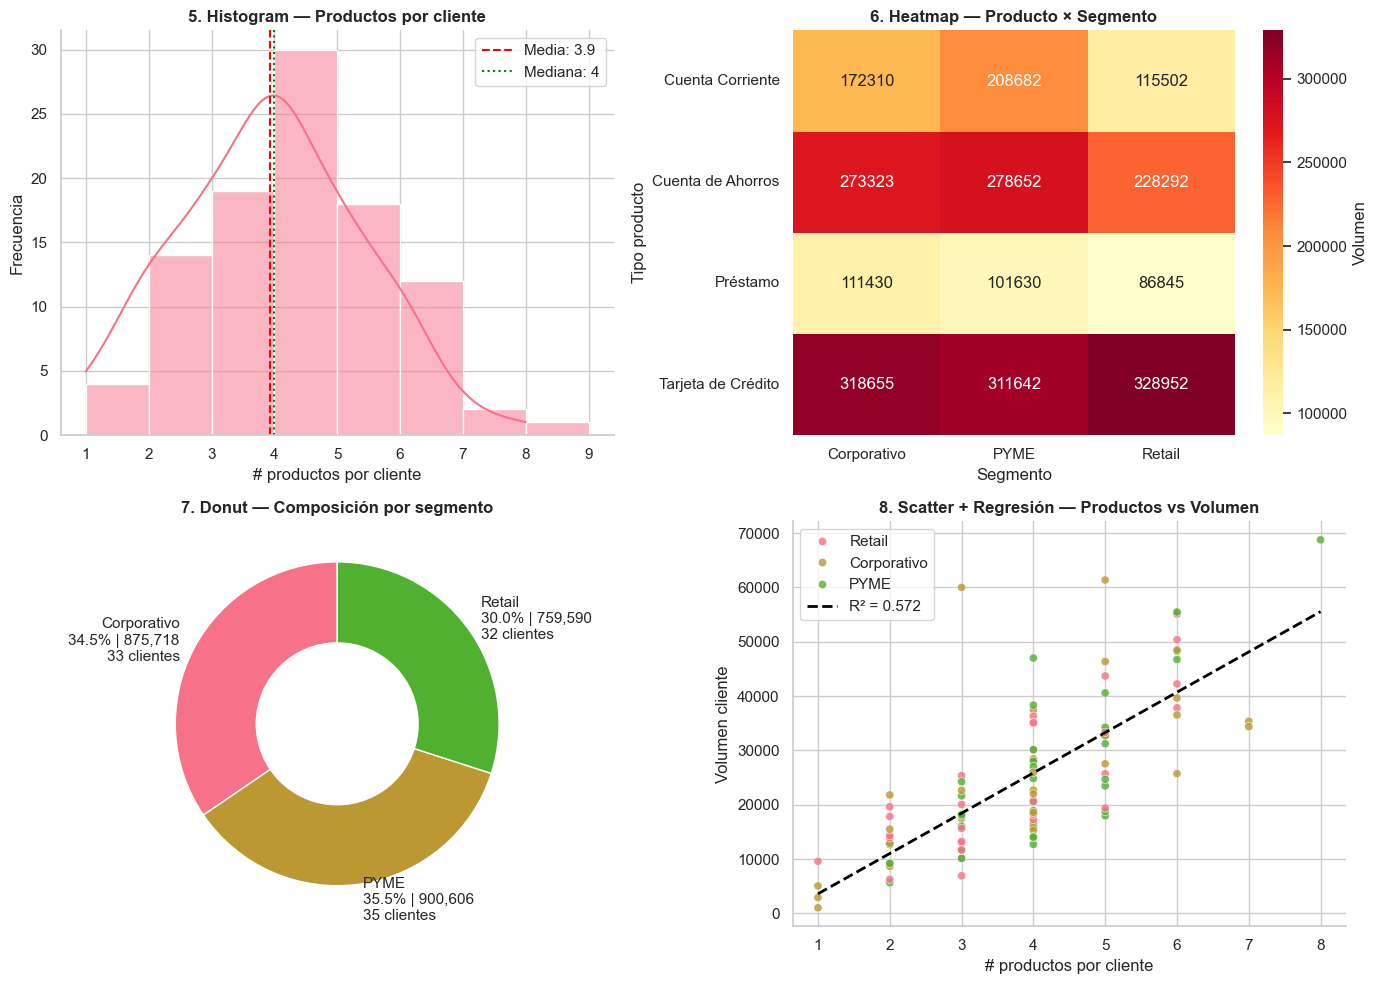

In [15]:
# TIER 2 — Importantes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
grafico_5_histogram_productos_por_cliente(datos["productos_por_cliente"], axes[0, 0])
grafico_6_heatmap_producto_segmento(datos["heatmap"], axes[0, 1])
grafico_7_donut_segmentos(datos["segmento_agg"], axes[1, 0])
grafico_8_scatter_regresion(datos["cliente_agg"], axes[1, 1])
plt.tight_layout()
plt.show()

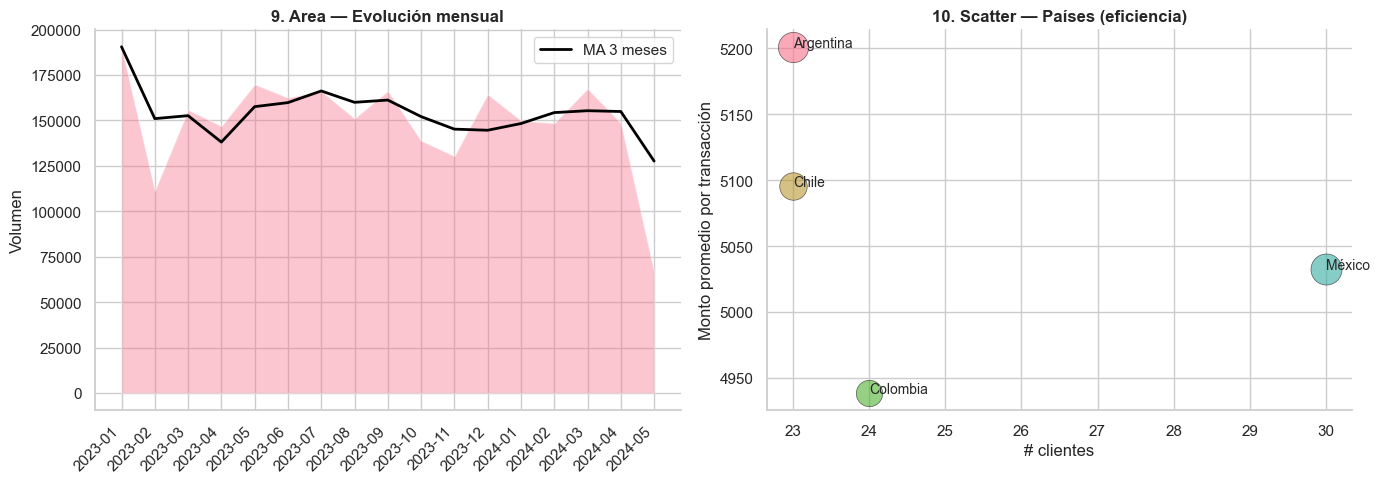

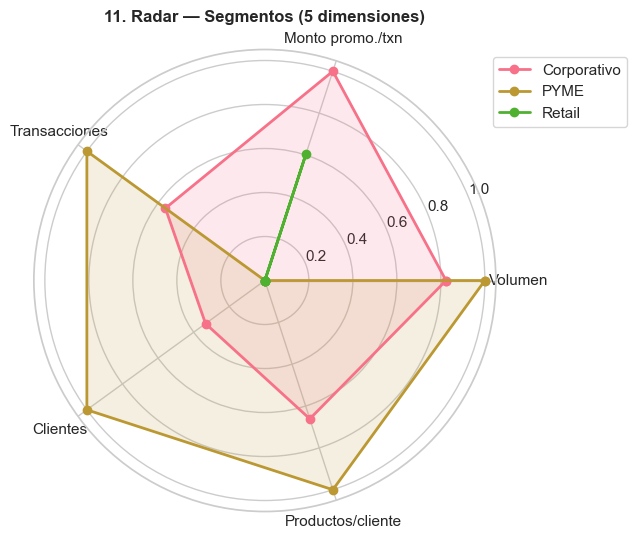

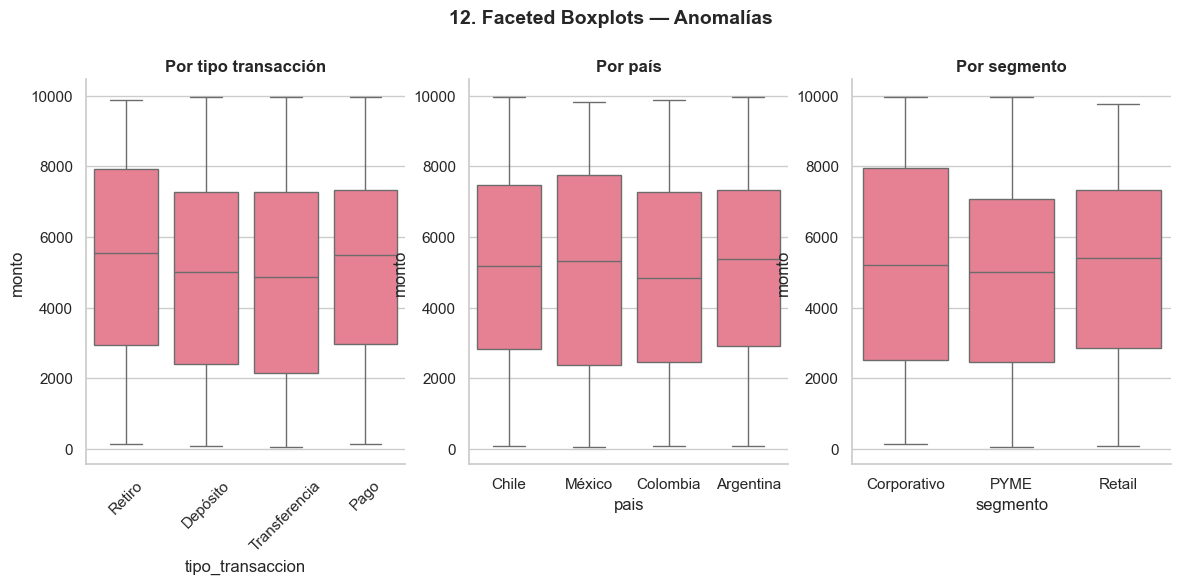

In [16]:
# TIER 3 — Complementarios (9, 10)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
grafico_9_area_evolucion_mensual(datos["mensual"], axes[0])
grafico_10_scatter_paises(datos["pais_scatter"], axes[1])
plt.tight_layout()
plt.show()

# 11. Radar
grafico_11_radar_segmentos(datos["radar"])
plt.show()

# 12. Faceted boxplots
grafico_12_faceted_boxplots(datos["tx_full"])
plt.show()

## Análisis Avanzado — Trayectoria de Clientes y Regresión Multivariable

In [19]:
# datos["tx_full"] ya contiene todas las columnas necesarias:
# id_cliente, id_producto, nombre_producto, pais, genero, segmento, fecha, monto
# No se requiere merge adicional.

# Top 5 clientes por volumen: trayectoria temporal
plot_customer_journey(datos["tx_full"], top_n=5)

KeyError: 'genero'

In [ ]:
# Trayectoria de un cliente individual (ajustar ID al rango 1001-1100)
plot_customer_journey(datos["tx_full"], customer_id=1046)

In [ ]:
# Regresión OLS: ¿Qué factores explican el volumen del cliente?
# Requiere: pip install statsmodels>=0.14.0
resultados = regresion_multivariable_volumen(datos["tx_full"])
print(f"\nR² del modelo: {resultados['R_squared']:.4f}")
print("\nCoeficientes:")
print(resultados["coeficientes"].to_string())

In [ ]:
from funciones.exportar import exportar_dashboard_data

resultado = regresion_multivariable_volumen(datos["tx_full"])
exportar_dashboard_data(datos, resultado)
